# Customer Churn Prediction 📉

**Goal:** predict which telecom customers are about to leave ("churn"), so the business can step in *before* they go.

Churn just means a customer cancelling their service. Keeping an existing customer is far cheaper than winning a new one, so even a rough early-warning model is genuinely useful.

**The plan for this notebook:**
1. **Load & inspect** the data
2. **Clean** it (fix data types, handle blanks)
3. **Explore** it (EDA) — find what actually drives churn
4. **Preprocess** — turn text into numbers, scale, and split
5. **Train** three models — Logistic Regression, Random Forest, XGBoost
6. **Tune & compare** them, then pick a winner
7. **Save** the final model so it's ready to reuse

**Dataset:** the Telco Customer Churn dataset — 7,043 customers and 21 columns describing their account, the services they use, and whether they churned.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load the data & first look

> **Getting the data:** this reads the Telco Customer Churn CSV from Google Drive. If you're running the notebook from the GitHub repo, grab the dataset (linked in the README) and change the path below to point to your own copy.

In [ ]:
df =pd.read_csv('/content/drive/MyDrive/ml datasets/customer_churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


In [ ]:
(df["Churn"].value_counts()/len(df))*100

,count
Churn,
No,73.463013
Yes,26.536987


### A number worth remembering: the classes are imbalanced

About **73% of customers stay** and only **~27% churn**. That lopsided split is called *class imbalance*, and it has one important consequence:

a lazy model that predicts *"nobody churns"* for everyone would still be ~73% accurate — while being completely useless. So **plain accuracy will mislead us here.** We'll keep this 27% in the back of our minds and, later on, both pick better metrics and tell our models to pay extra attention to the rare "churn" group.

## Basic Data cleaning

##### Why is TotalCharges stored as object?

In [ ]:
# df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [ ]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Missing values can be stored as
""
" "
"N/A"
"Unknown"
"-"
"NULL"

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# ...then fill those NaN (the tenure=0 customers) with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

### Drop `customerID` — and *why* (before we do it)

`customerID` is a **unique identifier**. It doesn't describe customer behaviour and carries **no predictive information**. Worse, if we leave it in, a flexible model can *memorise* it and fool us with a fake-perfect score. So we remove it.

In [ ]:
df = df.drop(columns=["customerID"])
print("Columns now:", df.shape[1])

Columns now: 20


### Encode the target

Models need numbers, so map `Churn`: Yes → 1, No → 0.

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

## Exploratory Data Analysis (EDA)

EDA is about *understanding the data* and pulling out **business insight**.We'll look at the numeric features, then categorical features.

**Numerical Features analysis **

In [ ]:
numerical_features= df.select_dtypes(include='number').columns

In [ ]:
numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [ ]:
numerical_features[1:4]

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

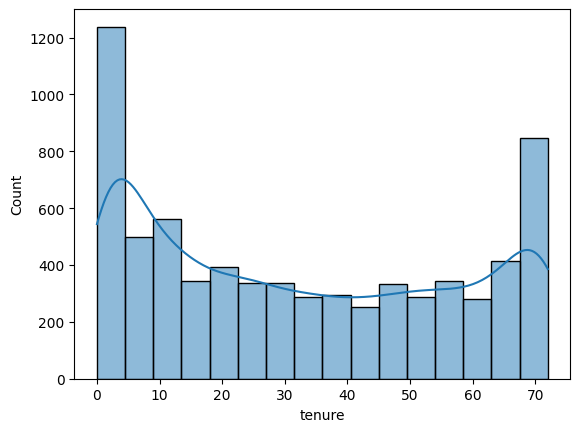

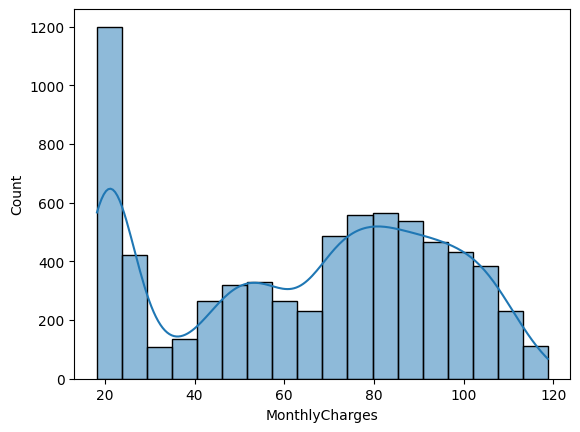

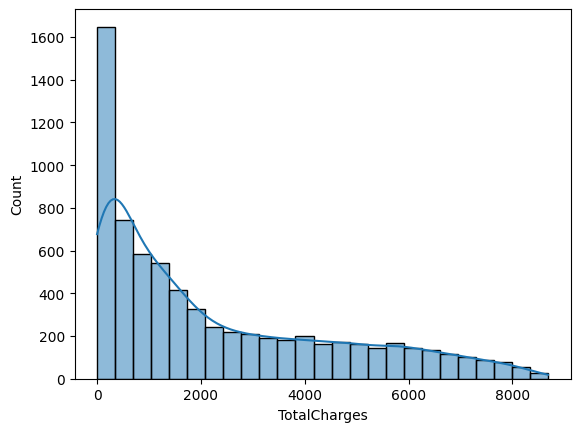

In [ ]:
for k in numerical_features[1:4] :
  sns.histplot(data=df, x=k,kde=True)
  plt.show()

In [ ]:
df.groupby("Churn")[numerical_features[1:4]].agg(["mean", "median"])

tenure        MonthlyCharges         TotalCharges          
            mean median           mean  median         mean    median
Churn                                                                
0      37.569965   38.0      61.265124  64.425  2549.911442  1679.525
1      17.979133   10.0      74.441332  79.650  1531.796094   703.550

In [ ]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 Months",
    "13-24 Months",
    "25-36 Months",
    "37-48 Months",
    "49-60 Months",
    "61-72 Months"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
churn_rate = df.groupby("tenure_group")["Churn"].mean() * 100

churn_rate

/tmp/ipykernel_5869/3500079231.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby("tenure_group")["Churn"].mean() * 100


,Churn
tenure_group,
0-12 Months,47.438243
13-24 Months,28.710938
25-36 Months,21.634615
37-48 Months,19.028871
49-60 Months,14.423077
61-72 Months,6.609808


Newer customers have a significantly higher churn rate, suggesting that the first year is a critical period for customer retention.

The first 12 months appear to be the highest-risk period for customers. This suggests the company should focus retention efforts heavily on newly acquired customers.

Price sensitivity — churners cluster at higher monthly charges.

In [ ]:
categorical_features = df.select_dtypes(include='object').columns

In [ ]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [ ]:
df.drop(columns="tenure_group", inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.groupby('gender')['Churn'].mean()

,Churn
gender,
Female,0.269209
Male,0.261603


In [ ]:
for col in categorical_features:
    print(f'Churn rate (%) by {col}:')
    print((df.groupby(col)['Churn'].mean() * 100).round(1).sort_values(ascending=False))
    print()

Churn rate (%) by gender:
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64

Churn rate (%) by Partner:
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64

Churn rate (%) by Dependents:
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64

Churn rate (%) by PhoneService:
PhoneService
Yes    26.7
No     24.9
Name: Churn, dtype: float64

Churn rate (%) by MultipleLines:
MultipleLines
Yes                 28.6
No                  25.0
No phone service    24.9
Name: Churn, dtype: float64

Churn rate (%) by InternetService:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64

Churn rate (%) by OnlineSecurity:
OnlineSecurity
No                     41.8
Yes                    14.6
No internet service     7.4
Name: Churn, dtype: float64

Churn rate (%) by OnlineBackup:
OnlineBackup
No                     39.9
Yes                    21.5
No internet service     7.4
Name: Churn, dtype: float64

Churn rate (%) by

In [ ]:
# Collapse the redundant 'No ... service' categories into 'No'
df = df.replace({'No internet service': 'No', 'No phone service': 'No'})

Customers on month-to-month contracts have a churn rate of approximately 42%, compared with only 3% for customers on two-year contracts. This suggests that longer contractual commitments are strongly associated with higher customer retention.

### Interaction analysis: do combinations create sharper segments?
Single features are useful, but *combinations* can be sharper. We only test combinations of the strong features we already found — we do **not** create features yet.

In [ ]:
pd.crosstab(
    df["InternetService"],
    df["Contract"],
    values=df["Churn"],
    aggfunc="mean"
) * 100

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,32.215863,9.298246,1.910828
Fiber optic,54.605263,19.294991,7.226107
No,18.893130,2.472527,0.783699


**Observation:** **Fiber + month-to-month = ~55%** — the worst segment in the data. The two risks *stack*.

In [ ]:
# Churn % for each InternetService + TechSupport combination
pd.crosstab(df["InternetService"], df["TechSupport"],
             values=df["Churn"], aggfunc="mean") * 100

TechSupport,No,Yes
InternetService,,
DSL,27.755430,9.677419
Fiber optic,49.372197,22.632794
No,7.404980,NaN


**Observation:** fiber customers **without tech support ~49%**, but **with tech support ~23%** — tech support roughly halves fiber churn.

### Are these signals independent, or overlapping?
Important check: if "risky" features describe the *same* customers, they aren't separate pieces of evidence.

In [ ]:
# Do month-to-month customers disproportionately use electronic check?
(df[df["Contract"] == "Month-to-month"]["PaymentMethod"]
 .value_counts(normalize=True) * 100).round(1)

,proportion
PaymentMethod,
Electronic check,47.7
Mailed check,23.0
Bank transfer (automatic),15.2
Credit card (automatic),14.0


**Observation:** ~48% of month-to-month customers use electronic check (vs ~34% overall) — the two "risk factors" overlap. **EDA shows association, not causation.** The model will sort out which effects are real.

### Extra checks because one model is *linear* (Logistic Regression)
A tree doesn't care about these; a linear model does.

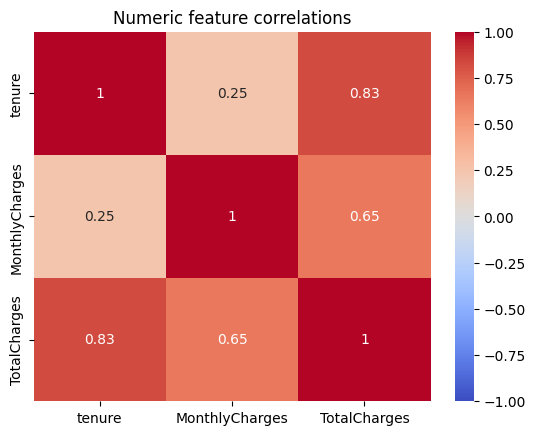

In [ ]:
# (1) Multicollinearity: are numeric features redundant with each other?
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlations")
plt.show()

In [ ]:
df[["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


#### What are "log-odds"?

Logistic Regression (coming up soon) doesn't model churn *probability* as a straight line — it models the **log-odds** of churn as a straight line. Odds are simply $\frac{p}{1-p}$, i.e. the chance of churning divided by the chance of staying, and log-odds is just the natural log of that.

Why check this? The model *assumes* each numeric feature nudges the log-odds up or down at a steady rate. The plot below bins a feature and shows the real log-odds for each bin: if the dots fall on a roughly straight line, that assumption holds and we can use the feature as-is. A strong curve would tell us to transform or bin it first.

In [ ]:
 #(2) Linearity in the log-odds: logistic regression assumes each numeric feature is
# linear vs the log-odds of churn
def logodds_by_bin(col):
    b = pd.qcut(df[col], 10, duplicates="drop")
    g = df.groupby(b, observed=True)["Churn"].mean().clip(0.01, 0.99)
    return np.log(g / (1 - g))

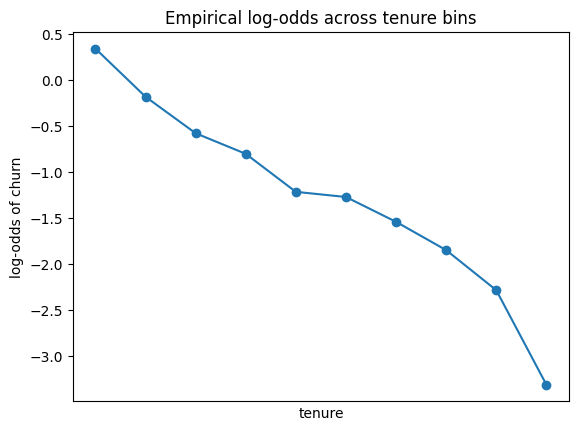

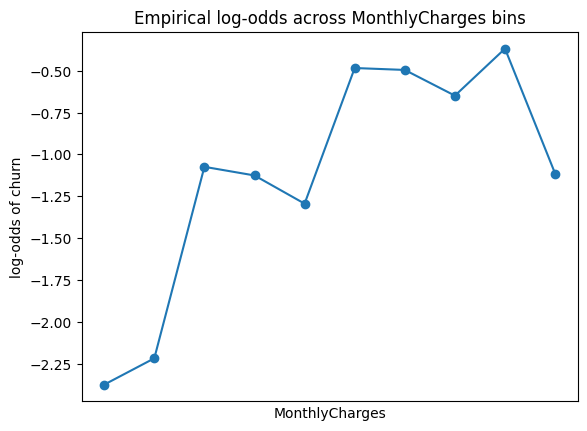

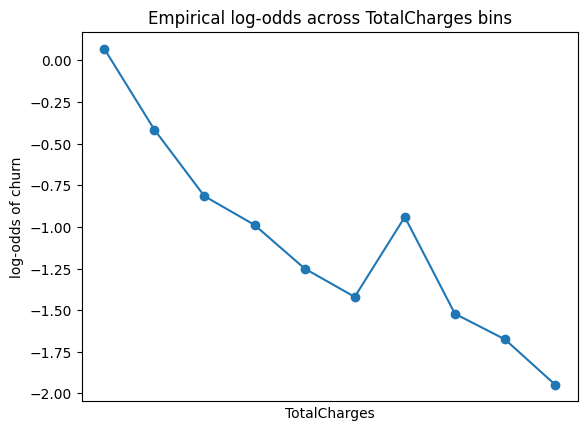

In [ ]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    logodds_by_bin(col).plot(marker="o")
    plt.title(f"Empirical log-odds across {col} bins")
    plt.ylabel("log-odds of churn")
    plt.xticks([])
    plt.show()

### Dropping `TotalCharges`

Look back at the correlation heatmap: `TotalCharges` is almost a product of the other two numeric columns — roughly `tenure × MonthlyCharges` — so it carries very little *new* information. When two features move together like this (called **multicollinearity**), a linear model's coefficients become unstable and harder to read. Since we already keep `tenure` and `MonthlyCharges`, we drop `TotalCharges` to keep the model clean and its coefficients trustworthy.

In [ ]:
df.drop(columns='TotalCharges',inplace =True)

**Observation:** the log-odds fall in a fairly straight line as tenure rises, so the linearity assumption holds — no transform needed. (A U-shape would mean we'd bin it or add a squared term.)

**Plan the Preprocessing Pipeline**

In [ ]:
# # 1. How many add-on services the customer has (more services = 'stickier')
# service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
#                 'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
# df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# # 2. Average spend per month of tenure (spending rate); replace(0,1) avoids /0
# df['avg_charge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# # 3. Brand-new customer flag (the first-year danger zone)
# df['is_new'] = (df['tenure'] < 12).astype(int)

# # 4. The deadly combo we spotted: fiber optic AND month-to-month
# df['fiber_m2m'] = ((df['InternetService'] == 'Fiber optic') &
#                    (df['Contract'] == 'Month-to-month')).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


##Encoding
Models need numbers. Two methods, depending on the column.

In [ ]:
# Binary Yes/No columns -> 1/0 (one column each)
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
               "TechSupport", "StreamingTV", "StreamingMovies"]
binary_map = {"Yes": 1, "No": 0, "Male": 1, "Female": 0}
for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [ ]:
# Multi-category columns (no natural order) -> one-hot; drop_first avoids the dummy-variable trap
df = pd.get_dummies(df, columns=["InternetService", "Contract", "PaymentMethod"],
                    drop_first=True, dtype=int)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,1,1,0,0,0,0,1,0


## Build X, y and split

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   MultipleLines                          5634 non-null   int64  
 7   OnlineSecurity                         5634 non-null   int64  
 8   OnlineBackup                           5634 non-null   int64  
 9   DeviceProtection                       5634 non-null   int64  
 10  TechSupport                            5634 non-null   int64  
 11  Streami

## Feature scaling
Standardize the numeric columns. Logistic Regression needs it; trees don't care, but it doesn't hurt them — so we scale once for everyone.

Scaling puts every numeric column on the same footing. For each value we compute its **standard score (z-score)**:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the column's mean and $\sigma$ its standard deviation. After this, every scaled column has a mean of 0 and a standard deviation of 1 — so a feature measured in hundreds (like `MonthlyCharges`) no longer drowns out one measured in single digits.

One rule we stick to: **`fit` the scaler on the training data only**, then apply those same numbers to the test data (that's why the code uses `fit_transform` on train but only `transform` on test). Peeking at the test set while scaling would leak information and make our scores look better than they really are.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # FIT on train
X_test_scaled  = scaler.transform(X_test)       # transform test only
print('Scaled. Example')

Scaled. Example


In [ ]:
# Put back into DataFrames with the original column names/index for readability
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [ ]:
X_train,X_test=X_train_scaled.copy(),X_test_scaled.copy()

## Handling the imbalance
Because only 26.5% churn, we tell each model to **care more about the rare class**. For most models that's `class_weight="balanced"`; XGBoost uses `scale_pos_weight`. This raises **recall** (we catch more churners).

## Model 1 — Logistic Regression (interpretable baseline)

### The maths, in plain terms

Logistic Regression takes a weighted sum of the features and squeezes it into a probability between 0 and 1 using the **sigmoid** function:

$$p = \frac{1}{1 + e^{-(b_0 + b_1x_1 + b_2x_2 + \dots)}}$$

Each weight $b_i$ captures how strongly feature $x_i$ pushes churn up or down. If the resulting $p$ is above a chosen cutoff (0.5 by default), we predict "churn."

Two settings in the code below are worth knowing:
- **`class_weight="balanced"`** — tells the model to treat the rare churners as more important. This is our imbalance fix.
- **`max_iter=1000`** — simply gives the solver enough steps to settle on the best weights.

We start here because it's fast, hard to overfit, and — best of all — **interpretable**: each weight reads back as a plain business insight, which we cash in at the very end of the notebook.

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

In [ ]:
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Predictions and churn probabilities
pred  = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:,1]

In [ ]:
pred

array([1, 0, 0, ..., 0, 0, 1])

In [ ]:
proba

array([0.80109782, 0.22285997, 0.02394386, ..., 0.13227884, 0.0572686 ,
       0.66055332])

### How we'll score the models

Because of the imbalance, we look past plain accuracy and watch three numbers instead:

- **Recall** — of all the customers who *actually* churned, what share did we catch? $\;\text{Recall} = \frac{TP}{TP + FN}$. This is our **most important** metric here: a missed churner is a lost customer.
- **Precision** — of everyone we *flagged* as churn, what share really churned? $\;\text{Precision} = \frac{TP}{TP + FP}$. Low precision means retention budget spent on people who were never going to leave.
- **ROC-AUC** — how well the model *ranks* churners above non-churners across every possible cutoff. 0.5 means random guessing, 1.0 means perfect.

(*TP* = true positives, *FN* = false negatives, *FP* = false positives.) There's usually a **trade-off**: push recall up and precision tends to slip. Which one matters more is a business decision — we return to it in "Threshold tuning.\"

In [ ]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             accuracy_score, roc_auc_score)

In [ ]:
print("Recall   :", round(recall_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))

Recall   : 0.82
Precision: 0.523
ROC-AUC  : 0.86


## Model 2 — Random Forest

A **Random Forest** builds hundreds of decision trees, each on a random slice of the rows and columns, then lets them **vote** on the answer. Because no single tree sees the whole picture, their individual mistakes tend to cancel out — giving a sturdier prediction than any one tree could. Unlike Logistic Regression, it can pick up non-linear patterns and feature interactions on its own, and it doesn't need scaled inputs.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=42, n_jobs=-1)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
pred  = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]
print("Recall   :", round(recall_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))

Recall   : 0.458
Precision: 0.643
ROC-AUC  : 0.839


## Model 3 — XGBoost

**XGBoost** also uses many trees, but it builds them **one after another** — each new tree focuses on the errors the previous ones made. This idea is called *boosting*, and it often makes the model very accurate, at the cost of being a bit more of a "black box." Here `scale_pos_weight` plays exactly the same imbalance-fixing role that `class_weight="balanced"` did for the other two models.

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's version of class_weight (ratio of stay:churn)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
                    subsample=0.9, scale_pos_weight=ratio,
                    eval_metric="logloss", random_state=42, n_jobs=-1)

In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
pred  = xgb.predict(X_test)
proba = xgb.predict_proba(X_test)[:, 1]
print("Recall   :", round(recall_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))

Recall   : 0.796
Precision: 0.534
ROC-AUC  : 0.855


## Compare the models

In [ ]:
# Collect the fitted models, then score them all the same way
models = {"Logistic Regression": logreg, "Random Forest": rf, "XGBoost": xgb}

rows = []
for name, model in models.items():
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "model":     name,
        "recall":    round(recall_score(y_test, pred), 3),
        "precision": round(precision_score(y_test, pred), 3),
        "roc_auc":   round(roc_auc_score(y_test, proba), 3),
    })
pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)

,model,recall,precision,roc_auc
0,Logistic Regression,0.820,0.523,0.860
1,XGBoost,0.796,0.534,0.855
2,Random Forest,0.458,0.643,0.839


**Observation:** Logistic Regression and XGBoost catch the most churners (high recall). Random Forest has lower recall despite decent accuracy - a reminder that **accuracy hides the churners we miss**.

## Hyperparameter tuning
We tune our two front-runners with cross-validation, scoring on ROC-AUC.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Tune Logistic Regression — just the regularization strength C
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    {"C": [0.05, 0.1, 0.5, 1, 2]}, scoring="roc_auc", cv=cv, n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("best C:", lr_grid.best_params_, "| CV ROC-AUC:", round(lr_grid.best_score_, 3))

best C: {'C': 2} | CV ROC-AUC: 0.839


In [ ]:
# Tune XGBoost — depth and learning rate
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", scale_pos_weight=ratio, random_state=42, n_jobs=-1),
    {"max_depth": [3, 4], "learning_rate": [0.03, 0.05], "n_estimators": [300]},
    scoring="roc_auc", cv=cv, n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("best params:", xgb_grid.best_params_, "| CV ROC-AUC:", round(xgb_grid.best_score_, 3))

best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300} | CV ROC-AUC: 0.841


**Observation:** the two land within a hair of each other on ROC-AUC. When performance ties, the **simpler, more interpretable model (Logistic Regression) is the better pick.**

## Threshold tuning
A model outputs a *probability*. The default cutoff is 0.5, but it's arbitrary. Lowering it flags more people as churn → **higher recall** (at the cost of more false alarms). This is a free way to catch more churners.

In [ ]:
# Use the tuned Logistic Regression and try different cutoffs
best_lr = lr_grid.best_estimator_
proba = best_lr.predict_proba(X_test)[:, 1]

rows = []
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred = (proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall":    round(recall_score(y_test, pred), 3),
        "precision": round(precision_score(y_test, pred), 3),
        "caught":    int(((pred == 1) & (y_test == 1)).sum()),
        "missed":    int(((pred == 0) & (y_test == 1)).sum()),
    })

pd.DataFrame(rows)

,threshold,recall,precision,caught,missed
0,0.25,0.954,0.407,356,17
1,0.30,0.941,0.428,351,22
2,0.35,0.925,0.450,345,28
3,0.40,0.877,0.466,327,46
4,0.45,0.855,0.495,319,54
5,0.50,0.820,0.523,306,67
6,0.55,0.786,0.558,293,80
7,0.60,0.737,0.579,275,98


**Observation:** dropping the threshold from 0.50 toward ~0.35 catches noticeably more churners. Pick the cutoff that matches the business's cost trade-off.

### Save the model

A trained model on its own isn't enough to deploy. New customer data also needs to go through the **same scaler**, land in the **same column order**, and use the **same threshold** — so we save all four together in one bundle.

In [ ]:
FINAL_THRESHOLD=0.40

In [ ]:
import joblib

joblib.dump(best_lr, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FINAL_THRESHOLD, "threshold.pkl")

print("Model, scaler and threshold saved!")

Model, scaler and threshold saved!


In [ ]:
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,PaperlessBilling,MonthlyCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
185,-1.025166,-0.437749,1.031376,-0.652662,-1.284605,-3.034225,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,0.833328,-1.331629,-0.887057,-0.524081,-0.52353,-0.558353,-0.527656,1.409146,-0.54275
2715,0.975452,-0.437749,-0.969579,-0.652662,0.353238,0.329573,1.162083,-0.632534,-0.733828,-0.722128,...,-0.799513,0.833328,-1.316672,-0.887057,1.908103,-0.52353,-0.558353,-0.527656,-0.709650,-0.54275
3825,-1.025166,-0.437749,1.031376,1.532186,0.803645,0.329573,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,-1.200007,-1.512772,-0.887057,1.908103,-0.52353,1.790982,-0.527656,-0.709650,1.84247
1807,-1.025166,-0.437749,-0.969579,-0.652662,-1.284605,0.329573,-0.860523,-0.632534,-0.733828,1.384796,...,-0.799513,-1.200007,0.381756,1.127324,-0.524081,-0.52353,-0.558353,-0.527656,1.409146,-0.54275
132,0.975452,-0.437749,-0.969579,-0.652662,1.417836,0.329573,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,-1.200007,-0.475768,-0.887057,-0.524081,-0.52353,1.790982,-0.527656,-0.709650,-0.54275


In [ ]:
model = joblib.load("churn_model.pkl")
scaler = joblib.load("scaler.pkl")
threshold = joblib.load("threshold.pkl")

In [ ]:
# The first 3 customers in our test set (by their original row index)
sample=X_test[0:5]

In [ ]:
sample

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,PaperlessBilling,MonthlyCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
185,-1.025166,-0.437749,1.031376,-0.652662,-1.284605,-3.034225,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,0.833328,-1.331629,-0.887057,-0.524081,-0.52353,-0.558353,-0.527656,1.409146,-0.54275
2715,0.975452,-0.437749,-0.969579,-0.652662,0.353238,0.329573,1.162083,-0.632534,-0.733828,-0.722128,...,-0.799513,0.833328,-1.316672,-0.887057,1.908103,-0.52353,-0.558353,-0.527656,-0.709650,-0.54275
3825,-1.025166,-0.437749,1.031376,1.532186,0.803645,0.329573,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,-1.200007,-1.512772,-0.887057,1.908103,-0.52353,1.790982,-0.527656,-0.709650,1.84247
1807,-1.025166,-0.437749,-0.969579,-0.652662,-1.284605,0.329573,-0.860523,-0.632534,-0.733828,1.384796,...,-0.799513,-1.200007,0.381756,1.127324,-0.524081,-0.52353,-0.558353,-0.527656,1.409146,-0.54275
132,0.975452,-0.437749,-0.969579,-0.652662,1.417836,0.329573,-0.860523,-0.632534,-0.733828,-0.722128,...,-0.799513,-1.200007,-0.475768,-0.887057,-0.524081,-0.52353,1.790982,-0.527656,-0.709650,-0.54275


In [ ]:
sample_scaled = scaler.transform(sample)

In [ ]:
probabilities = model.predict_proba(sample_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
probabilities

array([[2.14391320e-01, 7.85608680e-01],
       [8.83619562e-01, 1.16380438e-01],
       [9.99251950e-01, 7.48050327e-04],
       [8.87149690e-03, 9.91128503e-01],
       [9.73206933e-01, 2.67930668e-02]])

In [ ]:
probabilities[:,1]

array([7.85608680e-01, 1.16380438e-01, 7.48050327e-04, 9.91128503e-01,
       2.67930668e-02])

In [ ]:
predictions = (probabilities[:,1] >= 0.8).astype(int)

In [ ]:
predictions

array([0, 0, 0, 1, 0])

In [ ]:
y_test[:5]

,Churn
185,1
2715,0
3825,0
1807,1
132,0


## Why Logistic Regression is our pick — interpretability
Logistic Regression gives a **coefficient per feature**. Exponentiating it gives an **odds ratio** — a plain-English statement of how each feature changes churn odds. This is the business-friendly payoff a black-box model can't match.

In [ ]:
# Odds ratio for each feature (>1 = raises churn odds, <1 = lowers it)
odds = pd.Series(np.exp(best_lr.coef_[0]), index=X_train.columns)
odds.sort_values(ascending=False).round(2)

,0
InternetService_Fiber optic,2.25
StreamingMovies,1.38
StreamingTV,1.31
MultipleLines,1.22
PaymentMethod_Electronic check,1.18
PaperlessBilling,1.16
DeviceProtection,1.07
SeniorCitizen,1.06
PhoneService,1.05
Partner,1.02


**Observation:** the top features line up with the EDA story — month-to-month, fiber, electronic check raise churn odds; longer tenure and two-year contracts lower them. The model *confirms* what we saw.

## Wrapping up — what we learned

**The model:** all three models landed close on ROC-AUC (~0.84–0.86). We picked **Logistic Regression** because it matches the others on performance while staying fully explainable — and with threshold tuning it catches roughly **82% of churners**.

**What drives churn** (from the odds ratios and the EDA):
- **Raises churn:** month-to-month contracts, fiber-optic internet, electronic-check payment, high monthly charges, and being a new customer (short tenure).
- **Lowers churn:** one- and two-year contracts, longer tenure, and add-ons like tech support and online security.

**Business takeaways:**
- The first year is the danger zone — aim retention efforts at new customers.
- Nudge month-to-month customers toward longer contracts.
- Fiber customers without tech support churn heavily; bundling support could help.

**Where you could go next:** try the engineered features sketched earlier (tenure buckets, a services count, the fiber + month-to-month flag), calibrate the probabilities, or wrap the saved model in a small prediction function or app.